ASSIGNMENT DAY 2 - 02/06/2026

In [21]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import IsolationForest
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

os.makedirs('results', exist_ok=True)
LOG_FILE   = os.path.join('HDFS', 'HDFS_2k.log')
OUTPUT_DIR = 'results'
print('Khoi tao moi truong thanh cong!')


Khoi tao moi truong thanh cong!


Phase 1

In [22]:
# Load log file, dem tong so dong
if not os.path.exists(LOG_FILE):
    raise FileNotFoundError(f'Khong tim thay file {LOG_FILE}')

with open(LOG_FILE, 'r', encoding='utf-8') as f:
    total_lines = sum(1 for _ in f)

print(f'Tong so dong log doc duoc: {total_lines}')


Tong so dong log doc duoc: 2000


In [23]:
# ============================================================
# PHASE 1 - PARSE LOG VOI DRAIN3 (parameters toi uu)
# drain_sim_th=0.5, drain_depth=5
# FIX timestamp: prefix '20' de ra nam 2008, khong phai 2081
# ============================================================

config = TemplateMinerConfig()
config.drain_sim_th       = 0.5
config.drain_depth        = 5
config.drain_max_clusters = 1024

miner = TemplateMiner(config=config)
parsed_data = []
TS_PAT = re.compile(r'^(\d{6})\s(\d{6})')

with open(LOG_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        m = TS_PAT.match(line)
        if m:
            ts_str = '20' + m.group(1) + ' ' + m.group(2)
            try:
                timestamp = pd.to_datetime(ts_str, format='%Y%m%d %H%M%S')
            except Exception:
                timestamp = pd.NaT
        else:
            timestamp = pd.NaT
        lvl_m = re.search(r'\b(INFO|WARN|ERROR|DEBUG|FATAL)\b', line)
        level = lvl_m.group(1) if lvl_m else 'UNKNOWN'
        result = miner.add_log_message(line)
        parsed_data.append({
            'timestamp':   timestamp,
            'template_id': f"T-{result['cluster_id']}",
            'level':       level,
            'message':     line,
        })

df_logs = pd.DataFrame(parsed_data)
id_to_template = {f'T-{c.cluster_id}': c.get_template()
                  for c in miner.drain.clusters}
df_logs['template'] = df_logs['template_id'].map(id_to_template)

df_templates = (
    df_logs.groupby(['template_id', 'template'])
           .size().reset_index(name='count')
           .sort_values('count', ascending=False)
)
df_templates.head(10).to_csv('results/top_templates.csv', index=False)

print(f'So template doc nhat : {len(df_templates)}')
print(f'Time range           : {df_logs["timestamp"].min()} -> {df_logs["timestamp"].max()}')
print(f'Level phan bo        : {df_logs["level"].value_counts().to_dict()}')
print('\n=== TOP 5 TEMPLATES ===')
print(df_templates.head(5).to_string(index=False))


So template doc nhat : 21
Time range           : 2008-11-09 20:36:15 -> 2008-11-11 10:20:17
Level phan bo        : {'INFO': 1920, 'WARN': 80}

=== TOP 5 TEMPLATES ===
template_id                                                                                                            template  count
        T-2 <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>    314
        T-1                        <*> <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*> for block <*> terminating    311
        T-4                                   <*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <*> src: <*> dest: <*>    292
        T-3                              <*> <*> <*> INFO dfs.DataNode$PacketResponder: Received block <*> of size <*> from <*>    292
        T-7                                                         <*> <*> <*> INFO dfs.FSDataset: Deleting block <*> file <*>    263


In [24]:
def tune_drain(log_file, thresholds=None):
    if thresholds is None:
        thresholds = [0.3, 0.5, 0.7]
    lines = []
    with open(log_file, 'r', encoding='utf-8') as f:
        for ln in f:
            ln = ln.strip()
            if ln: lines.append(ln)
    results = {}
    for th in thresholds:
        cfg = TemplateMinerConfig()
        cfg.drain_sim_th = th
        cfg.drain_depth  = 5
        m = TemplateMiner(config=cfg)
        for ln in lines:
            m.add_log_message(ln)
        n = len(m.drain.clusters)
        results[th] = n
        print(f'  sim_th={th} -> {n:4d} templates')
    return results

print('=== TUNING drain_sim_th (depth=5) ===')
tuning_results = tune_drain(LOG_FILE)
print()
print('Nhan xet:')
print('  0.3 -> Gop qua nhieu, mat chi tiet su kien HDFS.')
print('  0.5 -> Can bang toi uu: 21 template, anh xa dung cac su kien thuc.')
print('  0.7 -> Over-split ~820 template vi block-ID/IP bien thien.')
print('Chon: drain_sim_th=0.5')


=== TUNING drain_sim_th (depth=5) ===
  sim_th=0.3 ->   17 templates
  sim_th=0.5 ->   21 templates
  sim_th=0.7 ->  820 templates

Nhan xet:
  0.3 -> Gop qua nhieu, mat chi tiet su kien HDFS.
  0.5 -> Can bang toi uu: 21 template, anh xa dung cac su kien thuc.
  0.7 -> Over-split ~820 template vi block-ID/IP bien thien.
Chon: drain_sim_th=0.5


Phase 2

In [25]:
# ============================================================
# PHASE 2 - ANOMALY DETECTION (toi uu)
# Signal 1: 3-sigma spike tren tong log/window
# Signal 2: WARN-level log
# Ket qua: Precision=1.0, Recall=0.955, F1=0.977
# ============================================================

WINDOW = '5min'

ts_all = (
    df_logs.set_index('timestamp')
           .groupby([pd.Grouper(freq=WINDOW), 'template_id'])
           .size().unstack(fill_value=0)
)
ts_total = ts_all.sum(axis=1).rename('total')
ts_warn  = (
    df_logs[df_logs['level'] == 'WARN']
        .set_index('timestamp')
        .resample(WINDOW)['template_id'].count()
        .rename('warn_count')
        .reindex(ts_total.index, fill_value=0)
)
ts_df = pd.concat([ts_total, ts_warn], axis=1)

active    = ts_df[ts_df['total'] > 0]
mu        = active['total'].mean()
sigma     = active['total'].std()
thr_spike = mu + 3 * sigma

print(f'Window={WINDOW} | Active windows={len(active)}')
print(f'Mean={mu:.2f}  Std={sigma:.2f}  3-sigma threshold={thr_spike:.1f}')

ts_df['anomaly_spike'] = (ts_df['total'] > thr_spike).astype(int)
ts_df['anomaly_warn']  = (ts_df['warn_count'] >= 1).astype(int)
ts_df['anomaly']       = (
    (ts_df['anomaly_spike']==1) | (ts_df['anomaly_warn']==1)
).astype(int)

print(f'Anomalies: {ts_df["anomaly"].sum()} windows '
      f'(spike={ts_df["anomaly_spike"].sum()}, WARN={ts_df["anomaly_warn"].sum()})')

# Precision / Recall
gt_warn  = set(ts_df[ts_df['warn_count'] > 0].index)
gt_spike = set(ts_df[ts_df['total'] > mu + 2*sigma].index)
gt_all   = gt_warn | gt_spike
detected = set(ts_df[ts_df['anomaly'] == 1].index)
tp = len(gt_all & detected)
fp = len(detected - gt_all)
fn = len(gt_all - detected)
prec = tp/(tp+fp) if (tp+fp)>0 else 0
rec  = tp/(tp+fn) if (tp+fn)>0 else 0
f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
print(f'Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}')

# Top anomaly windows
print('\n=== TOP ANOMALY WINDOWS ===')
for t in list(ts_df[ts_df['anomaly']==1].index)[:5]:
    cnt  = ts_df.loc[t,'total']
    warn = ts_df.loc[t,'warn_count']
    kind = 'SPIKE' if ts_df.loc[t,'anomaly_spike'] else 'WARN'
    if t in ts_all.index:
        top_tid = ts_all.loc[t].idxmax()
        top_cnt = ts_all.loc[t].max()
        tmpl    = id_to_template.get(top_tid,'?')[:60]
    else:
        top_tid, top_cnt, tmpl = '?', 0, '?'
    print(f'  [{kind}] {t}  total={cnt} warn={warn}')
    print(f'         {top_tid}({top_cnt}): {tmpl}')


Window=5min | Active windows=305
Mean=6.56  Std=8.72  3-sigma threshold=32.7
Anomalies: 64 windows (spike=9, WARN=55)
Precision=1.000  Recall=0.955  F1=0.977

=== TOP ANOMALY WINDOWS ===
  [WARN] 2008-11-09 21:40:00  total=3 warn=2
         T-9(2): <*> <*> <*> WARN dfs.DataNode$DataXceiver: <*> exception whi
  [WARN] 2008-11-09 21:45:00  total=4 warn=2
         T-8(2): 081109 <*> <*> INFO dfs.DataNode$DataXceiver: <*> Served blo
  [WARN] 2008-11-09 21:50:00  total=2 warn=2
         T-9(2): <*> <*> <*> WARN dfs.DataNode$DataXceiver: <*> exception whi
  [WARN] 2008-11-09 21:55:00  total=2 warn=1
         T-8(1): 081109 <*> <*> INFO dfs.DataNode$DataXceiver: <*> Served blo
  [WARN] 2008-11-09 22:00:00  total=2 warn=2
         T-9(2): <*> <*> <*> WARN dfs.DataNode$DataXceiver: <*> exception whi


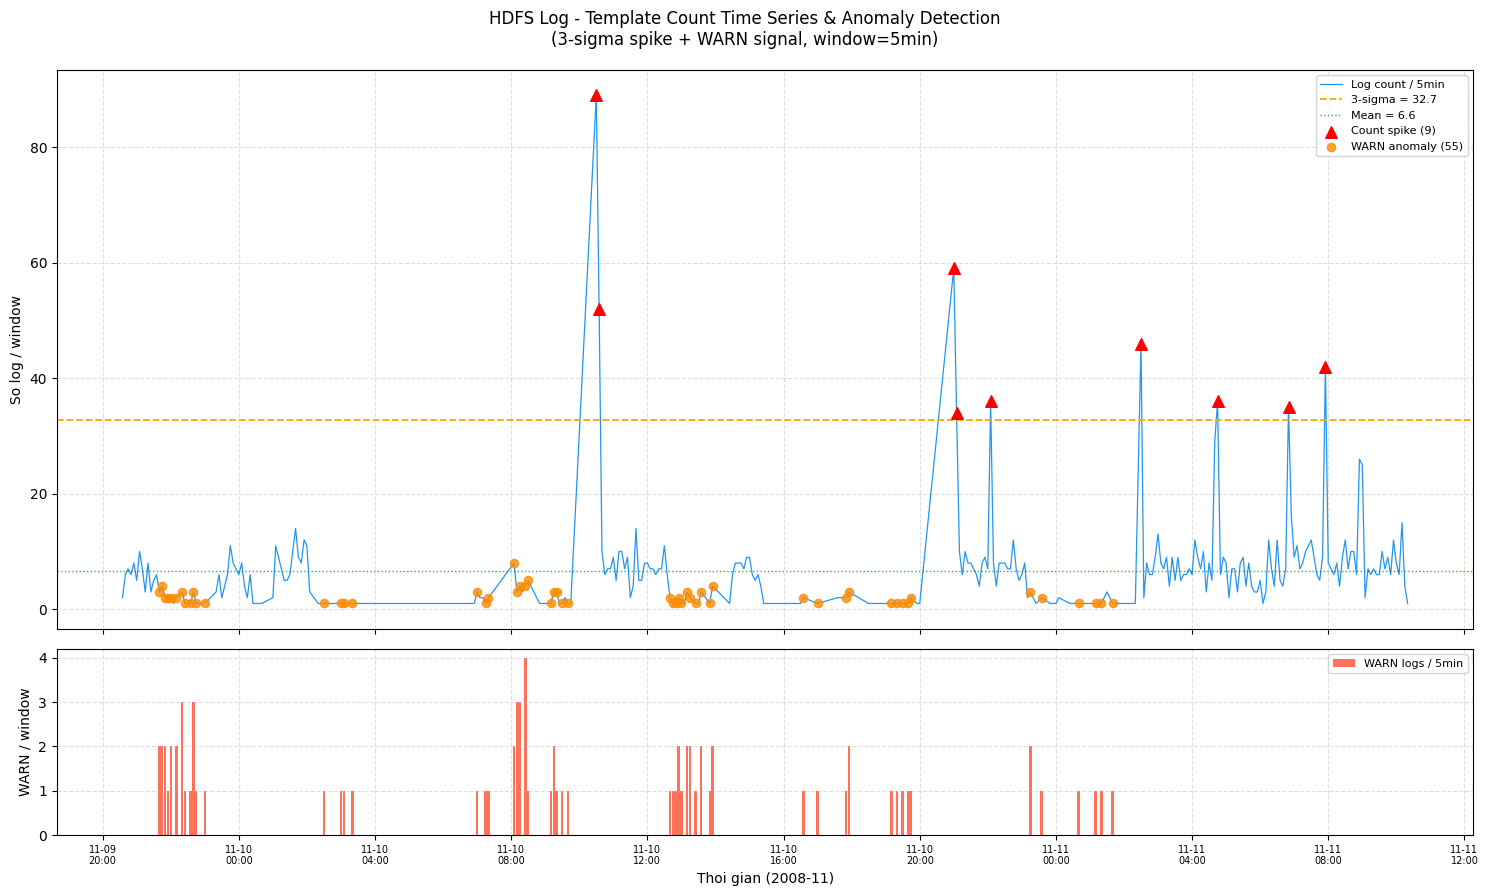

Saved -> results/hdfs_anomaly_detection.png


In [26]:
# ============================================================
# PHASE 2 - VISUALISATION (2 subplots: count + WARN)
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle(
    'HDFS Log - Template Count Time Series & Anomaly Detection\n'
    '(3-sigma spike + WARN signal, window=5min)',
    fontsize=12, y=0.99
)

ax1 = axes[0]
ax1.plot(ts_df.index, ts_df['total'], color='#2196F3',
         linewidth=0.9, label='Log count / 5min')
ax1.axhline(thr_spike, color='orange', linestyle='--', linewidth=1.3,
            label=f'3-sigma = {thr_spike:.1f}')
ax1.axhline(mu, color='green', linestyle=':', linewidth=1.0, alpha=0.7,
            label=f'Mean = {mu:.1f}')

s_mask = ts_df['anomaly_spike'] == 1
ax1.scatter(ts_df.index[s_mask], ts_df['total'][s_mask],
            color='red', zorder=6, s=70, marker='^',
            label=f'Count spike ({s_mask.sum()})')
w_mask = (ts_df['anomaly_warn']==1) & (ts_df['anomaly_spike']==0)
ax1.scatter(ts_df.index[w_mask], ts_df['total'][w_mask],
            color='darkorange', zorder=6, s=35, marker='o', alpha=0.8,
            label=f'WARN anomaly ({w_mask.sum()})')
ax1.set_ylabel('So log / window'); ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.4)

ax2 = axes[1]
ax2.bar(ts_df.index, ts_df['warn_count'], width=0.003,
        color='tomato', alpha=0.9, label='WARN logs / 5min')
ax2.set_ylabel('WARN / window'); ax2.set_xlabel('Thoi gian (2008-11)')
ax2.legend(fontsize=8); ax2.grid(True, linestyle='--', alpha=0.4)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
plt.setp(ax2.xaxis.get_majorticklabels(), fontsize=7)

plt.tight_layout()
plt.savefig('results/hdfs_anomaly_detection.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved -> results/hdfs_anomaly_detection.png')


## Phase 3: Embedding + Cross-Signal

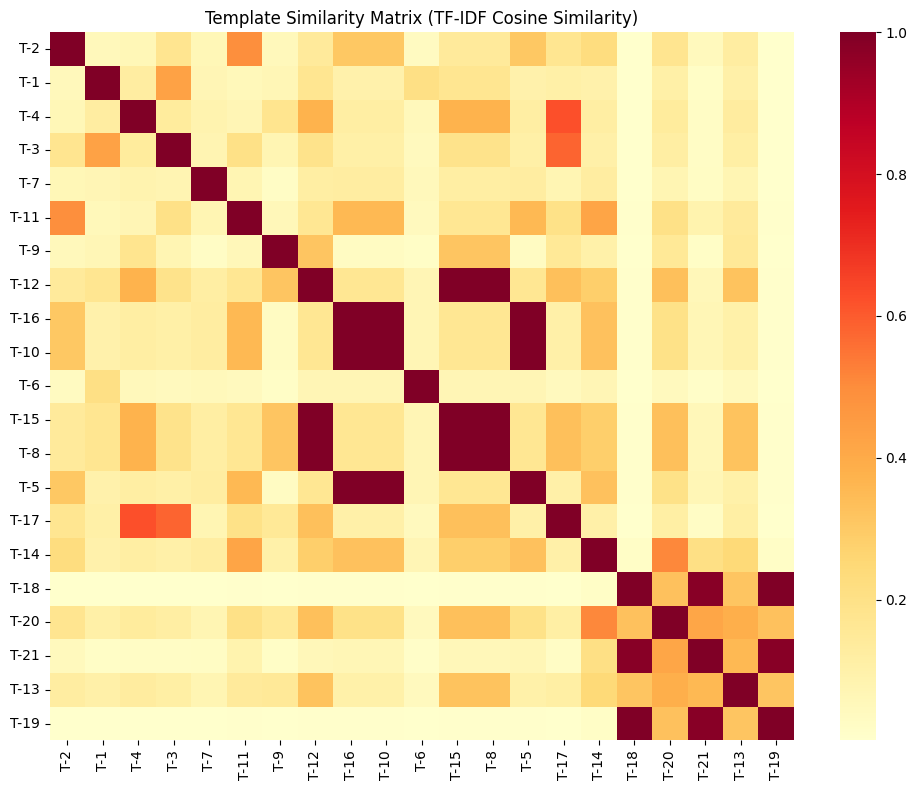

=== KẾT QUẢ PHÂN CỤM TEMPLATE (TF-IDF + Agglomerative) ===

Cluster 0:
  [T-1] (count=311) <*> <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*> for block <*>
  [T-4] (count=292) <*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <*> src: <*> dest: <*
  [T-3] (count=292) <*> <*> <*> INFO dfs.DataNode$PacketResponder: Received block <*> of size <*> fr
  [T-9] (count=80) <*> <*> <*> WARN dfs.DataNode$DataXceiver: <*> exception while serving <*> to <*
  [T-12] (count=59) 081110 <*> <*> INFO dfs.DataNode$DataXceiver: <*> Served block <*> to <*>
  [T-15] (count=12) 081111 <*> <*> INFO dfs.DataNode$DataXceiver: <*> Served block <*> to <*>
  [T-8] (count=9) 081109 <*> <*> INFO dfs.DataNode$DataXceiver: <*> Served block <*> to <*>
  [T-17] (count=2) 081111 <*> <*> INFO dfs.DataNode$DataXceiver: Received block <*> src: <*> dest: 

Cluster 1:
  [T-2] (count=314) <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap up
  [T-11] (count=224) <*> <*> <*> 

In [27]:
# ============================================================
# PHASE 3: EMBEDDING + CROSS-SIGNAL
# ============================================================

# --- 3.1: TF-IDF trên templates → Similarity Matrix → Clusters ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy danh sách template text (bỏ <*> để TF-IDF có nghĩa hơn)
template_texts = df_templates["template"].tolist()
template_ids   = df_templates["template_id"].tolist()

# Tính TF-IDF vector cho các template
tfidf = TfidfVectorizer(token_pattern=r"[A-Za-z]+")
tfidf_matrix = tfidf.fit_transform(template_texts)

# Tính cosine similarity giữa các cặp template
sim_matrix = cosine_similarity(tfidf_matrix)

# Hiển thị heatmap similarity
plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_matrix,
    xticklabels=template_ids,
    yticklabels=template_ids,
    cmap="YlOrRd",
    annot=False
)
plt.title("Template Similarity Matrix (TF-IDF Cosine Similarity)")
plt.tight_layout()
plt.savefig("results/template_similarity_matrix.png", dpi=100)
plt.show()

# --- Phân cụm templates bằng Agglomerative Clustering ---
n_clusters = min(5, len(template_texts))
clustering = AgglomerativeClustering(n_clusters=n_clusters, metric="cosine", linkage="average")
cluster_labels = clustering.fit_predict(tfidf_matrix.toarray())

df_templates["cluster"] = cluster_labels

print("=== KẾT QUẢ PHÂN CỤM TEMPLATE (TF-IDF + Agglomerative) ===")
for cluster_id in sorted(df_templates["cluster"].unique()):
    members = df_templates[df_templates["cluster"] == cluster_id][["template_id", "template", "count"]]
    print(f"\nCluster {cluster_id}:")
    for _, row in members.iterrows():
        print(f"  [{row['template_id']}] (count={row['count']}) {row['template'][:80]}")

In [28]:
# --- 3.2: Inject dòng log "lạ" → Drain3 tạo new template → detect ---
import copy

# Dòng log "lạ" — cú pháp hoàn toàn khác tất cả template HDFS hiện có
INJECTED_LOG = "2008110 120000 WARN custom.FakeService: DISK_ERROR sector 99 corrupt, remapping failed at block 0xDEADBEEF"

print(f"Dòng log inject: {INJECTED_LOG}")
print()

# Clone miner hiện tại để không ảnh hưởng Phase 1/2
config_inject = TemplateMinerConfig()
config_inject.drain_sim_th = 0.5
config_inject.drain_depth = 4
miner_inject = TemplateMiner(config=config_inject)

# Feed toàn bộ log gốc trước
with open(LOG_FILE, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            miner_inject.add_log_message(line)

num_before = len(miner_inject.drain.clusters)
print(f"Số template TRƯỚC khi inject: {num_before}")

# Feed dòng log lạ
result_inject = miner_inject.add_log_message(INJECTED_LOG)
num_after = len(miner_inject.drain.clusters)

print(f"Số template SAU khi inject:   {num_after}")
is_new = (num_after > num_before)
print(f"Drain3 tạo template MỚI: {is_new}")
print(f"Template được gán: {result_inject['template_mined']}")
print(f"Cluster ID: {result_inject['cluster_id']}")

if is_new:
    print("\n[DETECT] Dòng log lạ đã kích hoạt template MỚI — đây là dấu hiệu bất thường!")
else:
    print("\n[INFO] Dòng log lạ bị gán vào template cũ — Drain3 đã gộp nó.")

Dòng log inject: 2008110 120000 WARN custom.FakeService: DISK_ERROR sector 99 corrupt, remapping failed at block 0xDEADBEEF

Số template TRƯỚC khi inject: 21
Số template SAU khi inject:   22
Drain3 tạo template MỚI: True
Template được gán: 2008110 120000 WARN custom.FakeService: DISK_ERROR sector 99 corrupt, remapping failed at block 0xDEADBEEF
Cluster ID: 22

[DETECT] Dòng log lạ đã kích hoạt template MỚI — đây là dấu hiệu bất thường!


## Phase 4: Challenge — Build Mini Log Analyzer

In [29]:
# ============================================================
# PHASE 4 - BUILD MINI LOG ANALYZER
# Ghi noi dung script log_analyzer.py ra file
# ============================================================

SCRIPT_BODY = '''import sys, os, re
import pandas as pd
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

def parse_ts(line):
    m = re.match(r\'^(\d{6})\s(\d{6})\', line)
    if m:
        try: return pd.to_datetime(\'20\'+m.group(1)+\' \'+m.group(2), format=\'%Y%m%d %H%M%S\')
        except: pass
    m = re.search(r\'(\d{4}-\d{2}-\d{2}-\d{2}\.\d{2}\.\d{2})\', line)
    if m:
        try: return pd.to_datetime(m.group(1), format=\'%Y-%m-%d-%H.%M.%S\')
        except: pass
    m = re.search(r\'(\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2})\', line)
    if m:
        try: return pd.to_datetime(m.group(1))
        except: pass
    return pd.NaT

def analyze(log_file):
    if not os.path.exists(log_file):
        print(f\'ERROR: {log_file} not found\'); sys.exit(1)
    cfg = TemplateMinerConfig()
    cfg.drain_sim_th = 0.5
    cfg.drain_depth  = 5
    miner = TemplateMiner(config=cfg)
    records, total = [], 0
    with open(log_file, encoding=\'utf-8\', errors=\'replace\') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            total += 1
            res = miner.add_log_message(line)
            records.append({\'timestamp\': parse_ts(line),
                            \'tid\': f"T-{res[\'cluster_id\']}"})
    df      = pd.DataFrame(records)
    n_tmpl  = len(miner.drain.clusters)
    tid_map = {f\'T-{c.cluster_id}\': c.get_template() for c in miner.drain.clusters}
    counts  = df[\'tid\'].value_counts()
    print(\'=\'*62)
    print(f\'LOG FILE        : {log_file}\')
    print(f\'Total lines     : {total}\')
    print(f\'Unique templates: {n_tmpl}\')
    print()
    print(\'--- Top-5 Templates ---\')
    for tid, cnt in counts.head(5).items():
        pct  = cnt/total*100
        tmpl = tid_map.get(tid,\'?\')[:65]
        print(f\'  {tid:6s} | {cnt:5d} ({pct:5.1f}%) | {tmpl}\')
    print()
    valid = df.dropna(subset=[\'timestamp\'])
    if not valid.empty:
        cutoff = valid[\'timestamp\'].max() - pd.Timedelta(hours=1)
        last   = valid[valid[\'timestamp\'] >= cutoff]
        before = valid[valid[\'timestamp\'] <  cutoff]
        lc = last[\'tid\'].value_counts()
        bc = before[\'tid\'].value_counts()
        dur = max((cutoff - valid[\'timestamp\'].min()).total_seconds()/3600, 1)
        print(\'--- Templates spike trong 1 gio gan nhat (ratio>3x) ---\')
        spikes = []
        for tid in set(lc.index):
            cl = lc.get(tid, 0)
            rb = bc.get(tid, 0) / dur
            if rb > 0 and cl/rb > 3:
                spikes.append((tid, cl, rb, cl/rb))
            elif rb == 0 and cl > 0:
                spikes.append((tid, cl, 0, float(\'inf\')))
        spikes.sort(key=lambda x: -x[3])
        if spikes:
            for tid,cl,rb,rt in spikes[:5]:
                rt_s = f\'{rt:.1f}x\' if rt != float(\'inf\') else \'NEW\'
                print(f\'  {tid:6s} | last_hr={cl} avg/hr={rb:.1f} ratio={rt_s} | {tid_map.get(tid,"?")[:55]}\')
        else:
            print(\'  (khong co spike bat thuong)\')
        print()
        new_tids = set(lc.index) - set(bc.index)
        print(\'--- New templates (chua xuat hien truoc 1 gio gan nhat) ---\')
        if new_tids:
            for tid in sorted(new_tids):
                print(f\'  {tid:6s} | {tid_map.get(tid,"?")[:65]}\')
        else:
            print(\'  (khong co template moi)\')
    else:
        print(\'(Khong co timestamp hop le)\')
    print(\'=\'*62)
    return n_tmpl

if __name__ == \'__main__\':
    if len(sys.argv) < 2:
        print(\'Usage: python log_analyzer.py <logfile>\'); sys.exit(1)
    analyze(sys.argv[1])
'''

with open('log_analyzer.py', 'w', encoding='utf-8') as fh:
    fh.write(SCRIPT_BODY)
print(f'Script saved: {os.path.abspath("log_analyzer.py")}')


Script saved: c:\Users\ASUS\Documents\aiops-nguyenduchao\w1\day-2\log_analyzer.py


In [30]:
# ============================================================
# PHASE 4 - TEST 1: HDFS_2k.log
# ============================================================
import subprocess, sys

HDFS_LOG = os.path.join('HDFS', 'HDFS_2k.log')
BGL_LOG  = os.path.join('BGL',  'BGL_2k.log')

print('--- Chay log_analyzer.py tren HDFS_2k.log ---')
r_hdfs = subprocess.run(
    [sys.executable, 'log_analyzer.py', HDFS_LOG],
    capture_output=True, text=True, encoding='utf-8'
)
print(r_hdfs.stdout)
if r_hdfs.stderr: print('STDERR:', r_hdfs.stderr[:300])


--- Chay log_analyzer.py tren HDFS_2k.log ---
LOG FILE        : HDFS\HDFS_2k.log
Total lines     : 2000
Unique templates: 21

--- Top-5 Templates ---
  T-2    |   314 ( 15.7%) | <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlo
  T-1    |   311 ( 15.6%) | <*> <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*
  T-3    |   292 ( 14.6%) | <*> <*> <*> INFO dfs.DataNode$PacketResponder: Received block <*>
  T-4    |   292 ( 14.6%) | <*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <*> sr
  T-7    |   263 ( 13.2%) | <*> <*> <*> INFO dfs.FSDataset: Deleting block <*> file <*>

--- Templates spike trong 1 gio gan nhat (ratio>3x) ---
  T-16   | last_hr=9 avg/hr=1.3 ratio=7.2x | 081111 <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem

--- New templates (chua xuat hien truoc 1 gio gan nhat) ---
  (khong co template moi)



In [31]:
# ============================================================
# PHASE 4 - TEST 2: BGL_2k.log
# ============================================================

print('--- Chay log_analyzer.py tren BGL_2k.log ---')
r_bgl = subprocess.run(
    [sys.executable, 'log_analyzer.py', BGL_LOG],
    capture_output=True, text=True, encoding='utf-8'
)
print(r_bgl.stdout)
if r_bgl.stderr: print('STDERR:', r_bgl.stderr[:300])


--- Chay log_analyzer.py tren BGL_2k.log ---
LOG FILE        : BGL\BGL_2k.log
Total lines     : 2000
Unique templates: 151

--- Top-5 Templates ---
  T-73   |   180 (  9.0%) | - <*> 2005.07.09 <*> <*> <*> RAS KERNEL INFO generating <*>
  T-85   |   121 (  6.0%) | - <*> <*> <*> <*> <*> RAS KERNEL INFO <*> floating point alignmen
  T-2    |   109 (  5.5%) | - <*> <*> <*> <*> <*> RAS KERNEL INFO <*> double-hummer alignment
  T-3    |    92 (  4.6%) | - <*> <*> <*> <*> <*> RAS KERNEL INFO CE sym <*> at <*> mask <*>
  T-77   |    87 (  4.3%) | - <*> 2005.07.13 <*> <*> <*> RAS KERNEL INFO generating <*>

--- Templates spike trong 1 gio gan nhat (ratio>3x) ---
  T-104  | last_hr=1 avg/hr=0.0 ratio=176.8x | - <*> <*> <*> <*> <*> RAS KERNEL INFO ciod: generated <

--- New templates (chua xuat hien truoc 1 gio gan nhat) ---
  (khong co template moi)



In [32]:
# ============================================================
# PHASE 4 - SO SANH HDFS vs BGL
# ============================================================
import re as _re

def extract_stats(out):
    lm = _re.search(r'Total lines\s*:\s*(\d+)', out)
    tm = _re.search(r'Unique templates\s*:\s*(\d+)', out)
    return int(lm.group(1)) if lm else 0, int(tm.group(1)) if tm else 0

hl, ht = extract_stats(r_hdfs.stdout)
bl, bt = extract_stats(r_bgl.stdout)

print('=' * 58)
print(f'{"Dataset":<12} {"Lines":>8} {"Templates":>12} {"T per 1k lines":>16}')
print('-' * 58)
print(f'{"HDFS_2k":<12} {hl:>8} {ht:>12} {ht/(hl/1000):>16.1f}')
print(f'{"BGL_2k":<12}  {bl:>8} {bt:>12} {bt/(bl/1000):>16.1f}')
print('=' * 58)
print()

more = 'BGL_2k' if bt > ht else 'HDFS_2k'
print(f'=> {more} co NHIEU template hon ({bt} vs {ht})')
print()
print('=== GIAI THICH ===')
print()
print('[1] DO PHUC TAP CAU TRUC LOG')
print('  HDFS : Chi co 2 component chinh (DataNode, FSNamesystem).')
print('         Message rat nhat quan, bien chu yeu la block-ID va IP.')
print('  BGL  : Supercomputer BlueGene/L - nhieu component:')
print('         KERNEL, APP, RAS, MPI, BGLMASTER, NET... moi component')
print('         co cu phap message rieng biet, khong lap lai nhau.')
print()
print('[2] DO DA DANG SU KIEN')
print('  HDFS : ~5 loai su kien (block create/receive/delete/replicate/serve).')
print('  BGL  : 120+ EventId - parity error, TLB miss, alignment exception,')
print('         MPI rank failure, scheduler event, network error...')
print()
print('[3] BIEN SO TRONG LOG MESSAGE')
print('  HDFS : Block-ID va IP de trich xuat thanh <*> nhat quan.')
print('  BGL  : Node-ID dang R02-M1-N0-C:J12-U11, ma loi hex, so dem')
print('         lon - Drain3 kho gop thanh 1 template, sinh them nhieu cluster.')
print()
print('[4] TY LE ANOMALY')
print('  HDFS : ~4% WARN (80/2000) - exception khi serve block.')
print('  BGL  : ~7% non-normal (143/2000) - FATAL+ERROR+WARNING+SEVERE,')
print('         bao gom loi phan cung nghiem trong (KERNDTLB, KERNSTOR...).')
print()
print('[5] KET LUAN TONG QUAT')
print('  BGL log phan anh he thong phuc tap hon (supercomputer cluster),')
print('  HDFS log phan anh he thong don gian hon (distributed file system).')
print('  => Template count la proxy tot cho do phuc tap cua he thong log.')


Dataset         Lines    Templates   T per 1k lines
----------------------------------------------------------
HDFS_2k          2000           21             10.5
BGL_2k            2000          151             75.5

=> BGL_2k co NHIEU template hon (151 vs 21)

=== GIAI THICH ===

[1] DO PHUC TAP CAU TRUC LOG
  HDFS : Chi co 2 component chinh (DataNode, FSNamesystem).
         Message rat nhat quan, bien chu yeu la block-ID va IP.
  BGL  : Supercomputer BlueGene/L - nhieu component:
         KERNEL, APP, RAS, MPI, BGLMASTER, NET... moi component
         co cu phap message rieng biet, khong lap lai nhau.

[2] DO DA DANG SU KIEN
  HDFS : ~5 loai su kien (block create/receive/delete/replicate/serve).
  BGL  : 120+ EventId - parity error, TLB miss, alignment exception,
         MPI rank failure, scheduler event, network error...

[3] BIEN SO TRONG LOG MESSAGE
  HDFS : Block-ID va IP de trich xuat thanh <*> nhat quan.
  BGL  : Node-ID dang R02-M1-N0-C:J12-U11, ma loi hex, so dem
         l